In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [89]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')

BATCH_SIZE = 128
EPOCHS = 30
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cpu


In [85]:
# ==========================================
# 2. DATASET WITH AUGMENTATION
# ==========================================
class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train', augment=False):
        self.mode = mode
        self.augment = augment

        data = np.load(file_path)
        if mode == 'train':
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")
        elif mode == 'test':
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        self.x = torch.from_numpy(self.x).float() / 255.0
        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx].clone()
        
        if self.augment and self.mode == 'train':
            # Random horizontal flip (doodles are mostly symmetric)
            if torch.rand(1).item() > 0.5:
                img = img.view(28, 28).flip(1).view(784)
            # Small noise injection
            img = (img + torch.randn_like(img) * 0.03).clamp(0, 1)

        if self.mode == 'train':
            return img, self.y[idx]
        return img


In [86]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.85 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
# Augmented loader for training
aug_dataset = QuickDrawDataset(TRAIN_FILE, mode='train', augment=True)
aug_train_dataset, _ = random_split(
    aug_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
# 3. Create Loaders
train_loader = DataLoader(aug_train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,       batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loaded 60000 training samples. Classes: 15
Loaded 60000 training samples. Classes: 15
Train samples: 51000 | Validation samples: 9000


In [105]:
def train(model, epochs=30, lr=1e-3, weight_decay=1e-4, label_smoothing=0.1, desc="Model"):
    model = model.to(DEVICE)
    
    # AdamW + cosine schedule
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-5)
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val = 0
    best_state = None
    patience, counter = 5, 0
    
    for epoch in range(epochs):
        # Train 
        model.train()
        t_loss, correct, total = 0, 0, 0
        for x, y in train_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            t_loss += loss.item(); total += y.size(0)
            correct += out.argmax(1).eq(y).sum().item()
        train_losses.append(t_loss / len(train_loader))
        train_accs.append(100. * correct / total)
        
        # Validate 
        model.eval()
        v_loss, correct, total = 0, 0, 0
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(DEVICE), y.to(DEVICE)
                out = model(x)
                v_loss += criterion(out, y).item()
                total += y.size(0)
                correct += out.argmax(1).eq(y).sum().item()
        val_losses.append(v_loss / len(val_loader))
        val_accs.append(100. * correct / total)
        
        scheduler.step()
        
        if val_accs[-1] > best_val:
            best_val = val_accs[-1]
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                print(f"  Early stop at epoch {epoch+1}")
                break
        
        if (epoch+1) % 5 == 0 or epoch == 0:
            print(f"  [{desc}] Ep {epoch+1:2d}/{epochs} | Train: {train_accs[-1]:.1f}% | Val: {val_accs[-1]:.1f}% | Best: {best_val:.1f}%")
    
    # Restore best weights
    model.load_state_dict(best_state)
    print(f" -> Best Val Accuracy: {best_val:.2f}%")
    return train_losses, val_losses, train_accs, val_accs, best_val

def count_params(model):
    return sum(p.numel() for p in model.parameters())

Pancake parameters: 1,336,335

 ._. Training Pancake ._. 

  [Model] Ep  1/20 | Train: 65.7% | Val: 72.1% | Best: 72.1%
  [Model] Ep  5/20 | Train: 83.9% | Val: 78.0% | Best: 78.2%
  [Model] Ep 10/20 | Train: 94.6% | Val: 79.2% | Best: 79.2%
  [Model] Ep 15/20 | Train: 99.2% | Val: 79.2% | Best: 79.2%
  Early stop at epoch 19
 -> Best Val Accuracy: 79.22%


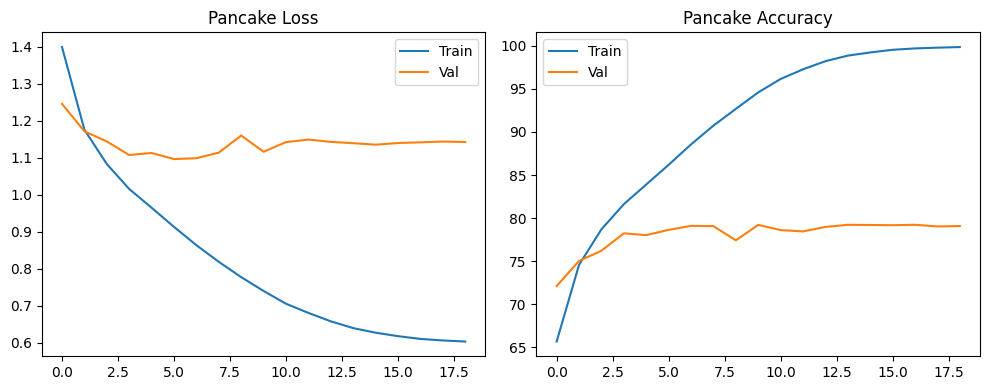

In [113]:
class PancakeMLP(nn.Module): 
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(784, 1024),
            nn.GELU(),

            nn.Linear(1024, 512),
            nn.GELU(),

            nn.Linear(512, 15)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)                 
        return self.model(x)
    
# Create and check Pancake 
pancake = PancakeMLP() 
pancake_params = count_params(pancake) 
print(f"Pancake parameters: {pancake_params:,}")
print("\n ._. Training Pancake ._. \n") 
pancake_history = train(pancake, epochs=20)
# Plot Pancake 
fig, axes = plt.subplots(1, 2, figsize=(10, 4)) 
axes[0].plot(pancake_history[0], label='Train') 
axes[0].plot(pancake_history[1], label='Val') 
axes[0].set_title('Pancake Loss') 
axes[0].legend() 
axes[1].plot(pancake_history[2], label='Train') 
axes[1].plot(pancake_history[3], label='Val') 
axes[1].set_title('Pancake Accuracy') 
axes[1].legend() 
plt.tight_layout() 
plt.savefig('pancake_curves.png') 
plt.show()

Tower parameters: 445,455

 ._. Training Tower ._. 

  [Model] Ep  1/20 | Train: 56.6% | Val: 68.3% | Best: 68.3%
  [Model] Ep  5/20 | Train: 75.8% | Val: 76.5% | Best: 76.5%
  [Model] Ep 10/20 | Train: 80.8% | Val: 79.5% | Best: 79.5%
  [Model] Ep 15/20 | Train: 83.5% | Val: 80.7% | Best: 80.7%
  [Model] Ep 20/20 | Train: 84.6% | Val: 81.0% | Best: 81.0%
 -> Best Val Accuracy: 80.98%


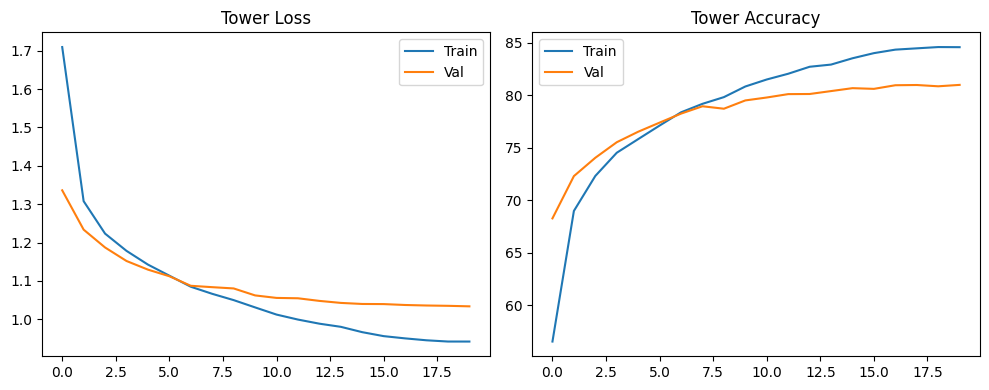

In [65]:
class TowerMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(784, 384),
            nn.BatchNorm1d(384),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(384, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.25),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.GELU(),

            nn.Linear(32, 15)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)                 
        return self.model(x)
    
tower = TowerMLP()
tower_params = count_params(tower)
print(f"Tower parameters: {tower_params:,}")

print("\n ._. Training Tower ._. \n")
tower_history = train(tower, epochs=20)

# Plot Tower
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(tower_history[0], label='Train')
axes[0].plot(tower_history[1], label='Val')
axes[0].set_title('Tower Loss')
axes[0].legend()
axes[1].plot(tower_history[2], label='Train')
axes[1].plot(tower_history[3], label='Val')
axes[1].set_title('Tower Accuracy')
axes[1].legend()
plt.tight_layout()
plt.savefig('tower_curves.png')
plt.show()

Champion parameters: 361,103

 ._. Training Champion ._. 

  [Model] Ep  1/30 | Train: 62.0% | Val: 70.7% | Best: 70.7%
  [Model] Ep  5/30 | Train: 76.6% | Val: 77.9% | Best: 77.9%
  [Model] Ep 10/30 | Train: 81.4% | Val: 79.3% | Best: 79.3%
  [Model] Ep 15/30 | Train: 84.6% | Val: 79.7% | Best: 79.8%
  [Model] Ep 20/30 | Train: 86.7% | Val: 80.4% | Best: 80.5%
  Early stop at epoch 22
 -> Best Val Accuracy: 80.46%


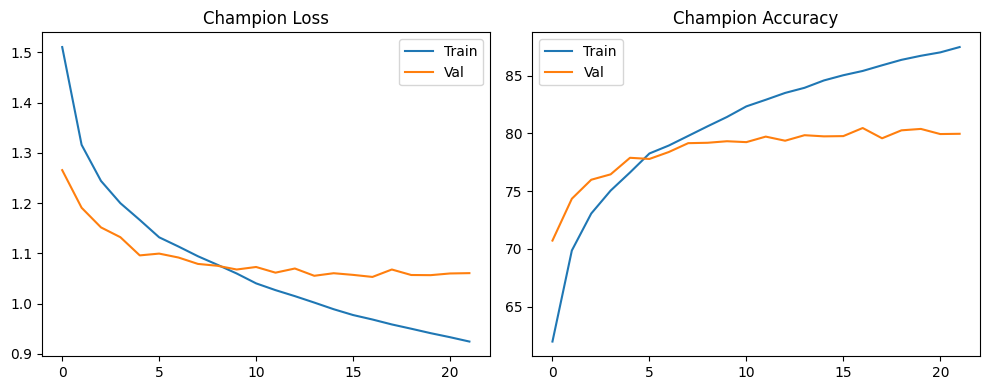

In [ ]:
class ChampionMLP(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.model = nn.Sequential(
            nn.Linear(784, 384),
            nn.BatchNorm1d(384),
            nn.GELU(),
            nn.Dropout(0.2),

            nn.Linear(384, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            nn.Dropout(0.1),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.GELU(),

            nn.Linear(64, 15)
        )

    def forward(self, x):
        x = x.view(x.size(0), -1)                 
        return self.model(x)
    
champion = ChampionMLP()
champion_params = count_params(champion)
print(f"Champion parameters: {champion_params:,}")

print("\n ._. Training Champion ._. \n")
champion_history = train(champion, epochs=20)

# Plot Champion
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(champion_history[0], label='Train')
axes[0].plot(champion_history[1], label='Val')
axes[0].set_title('Champion Loss')
axes[0].legend()
axes[1].plot(champion_history[2], label='Train')
axes[1].plot(champion_history[3], label='Val')
axes[1].set_title('Champion Accuracy')
axes[1].legend()
plt.tight_layout()
plt.savefig('champion_curves.png')
plt.show()

In [99]:
print("\n" + "="*60)
print("SAVING CHAMPION MODEL AND GENERATING SUBMISSION")
print("="*60)

model = champion

# Save model weights
torch.save(model.state_dict(), 'champion_model.pth')
print("✅ Saved champion model to 'champion_model.pth'")

# Generate submission
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            if isinstance(batch, list):
                X = batch[0].to(DEVICE)
            else:
                X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

print("Running inference on test set...")
predictions = get_predictions(champion, test_loader)

# Save submission
submission_file = "submission.txt"
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)

print(f"✅ Saved {len(predictions)} predictions to '{submission_file}'")
print(f"Sample predictions (first 20): {predictions[:20]}")


SAVING CHAMPION MODEL AND GENERATING SUBMISSION
✅ Saved champion model to 'champion_model.pth'
Loaded 15000 test images.
Running inference on test set...
✅ Saved 15000 predictions to 'submission.txt'
Sample predictions (first 20): [6, 11, 5, 5, 0, 1, 14, 9, 14, 8, 9, 7, 11, 11, 13, 8, 13, 12, 11, 3]


In [100]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [ ]:
def print_model_size(model):
    total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(model)


Model Statistics:
  Total Parameters: 361,103
  ✅ Parameter count is within limits.


In [ ]:
from torchinfo import summary 
print(summary(champion, input_size=(1, 784)))